# Principal Component Analysis

### Fewer columns, almost the same information

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | What a principal component is, how to compute PCA from the covariance matrix by hand, how many components to keep, and when reducing dimensions helps a downstream model rather than hurting it |
| **You should already know** | Matrix multiplication. Eigenvectors help but the notebook explains what is needed |
| **Datasets** | UCI Dry Bean (13,611 × 16), Breast Cancer Wisconsin (569 × 30) |
| **Runtime** | About a minute on a laptop CPU |
| **Next** | [06-03 t-SNE](../03-t-sne/) · [06-04 UMAP](../04-umap/) |

---

## 1. The idea

The Dry Bean dataset has sixteen measurements per bean, but they are not sixteen
independent facts. `Area`, `Perimeter`, `ConvexArea` and `EquivDiameter` all
essentially say *how big is it*. Knowing one tells you most of the others.

PCA finds new axes that are combinations of the old ones, ordered so the first
captures as much variation as possible, the second as much of what is left, and
so on. Keep the first few and you have discarded columns without discarding
much information.

The geometric picture: imagine the data as an elongated cloud. The first
principal component points along the longest direction of that cloud. The second
points along the longest direction perpendicular to the first. PCA is a
rotation, chosen so that variance concentrates in the earliest axes.

In [1]:
import sys
import pathlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0

X, y = datasets.dry_bean()
correlation = X.corr().abs()
upper = correlation.where(np.triu(np.ones(correlation.shape), k=1).astype(bool))
pairs = upper.stack().sort_values(ascending=False)

print(f"{X.shape[0]:,} beans, {X.shape[1]} measurements")
print("\nthe most redundant pairs of columns:")
print(pairs.head(5).round(4).to_string())

13,611 beans, 16 measurements

the most redundant pairs of columns:
Area          ConvexArea       0.9999
Compactness   ShapeFactor3     0.9987
Perimeter     EquivDiameter    0.9914
AspectRation  Compactness      0.9877
ConvexArea    EquivDiameter    0.9852


Several pairs of columns are correlated above 0.99. Sixteen measurements, far
fewer independent facts.

## 2. The maths

**Centre the data first.** Subtract each column's mean. PCA is about variance
around the centre, and if you skip this the first component just points at the
mean.

**Scale it too**, when the columns are in different units — which they are here.
Variance is measured in squared units, so an unscaled `Area` column would carry
essentially all of it and the first component would simply be `Area`.

Then compute the **covariance matrix**, which records how every pair of columns
varies together:

$$C = \frac{1}{n-1} X^\top X$$

The principal components are the **eigenvectors** of $C$, and each one's
**eigenvalue** is the variance along it. The eigenvector with the largest
eigenvalue is the first principal component.

If eigenvectors are unfamiliar, the thing to hold on to is this: an eigenvector
of $C$ is a direction that $C$ stretches without turning, and its eigenvalue is
how much stretching happens. PCA wants the direction that gets stretched most,
because that is the direction the data varies most along.

## 3. From scratch

In [2]:
from sklearn.preprocessing import StandardScaler


class PCAScratch:
    """PCA through the eigendecomposition of the covariance matrix."""

    def __init__(self, n_components=2):
        self.n_components = n_components

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        self.mean_ = X.mean(axis=0)
        centred = X - self.mean_

        covariance = np.cov(centred, rowvar=False)

        # eigh, not eig: the covariance matrix is symmetric, so eigh is faster
        # and returns real values instead of complex ones with zero imaginary part.
        eigenvalues, eigenvectors = np.linalg.eigh(covariance)

        # eigh returns them ascending; we want the largest variance first.
        order = np.argsort(eigenvalues)[::-1]
        eigenvalues, eigenvectors = eigenvalues[order], eigenvectors[:, order]

        self.components_ = eigenvectors[:, :self.n_components].T
        self.explained_variance_ = eigenvalues[:self.n_components]
        self.explained_variance_ratio_ = eigenvalues[:self.n_components] / eigenvalues.sum()
        return self

    def transform(self, X):
        return (np.asarray(X, dtype=float) - self.mean_) @ self.components_.T

    def inverse_transform(self, Z):
        """Rotate back into the original space. Whatever was dropped stays dropped."""
        return np.asarray(Z, dtype=float) @ self.components_ + self.mean_


X_scaled = StandardScaler().fit_transform(X)

mine = PCAScratch(n_components=16).fit(X_scaled)

from sklearn.decomposition import PCA

theirs = PCA(n_components=16, random_state=SEED).fit(X_scaled)

print("explained variance ratio, first five components")
print(f"  ours    : {np.round(mine.explained_variance_ratio_[:5], 5)}")
print(f"  sklearn : {np.round(theirs.explained_variance_ratio_[:5], 5)}")
print(f"\nlargest disagreement: "
      f"{np.abs(mine.explained_variance_ratio_ - theirs.explained_variance_ratio_).max():.2e}")

explained variance ratio, first five components
  ours    : [0.55466 0.26431 0.08007 0.05114 0.02739]
  sklearn : [0.55466 0.26431 0.08007 0.05114 0.02739]

largest disagreement: 2.22e-16


### How much do you keep?

80% of the variance needs 2 of 16 components
90% of the variance needs 4 of 16 components
95% of the variance needs 4 of 16 components
99% of the variance needs 7 of 16 components


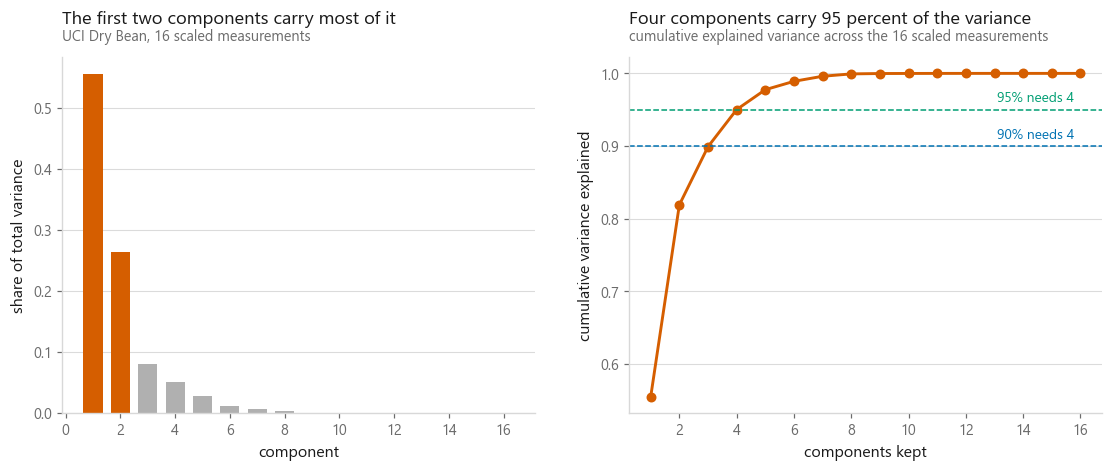

In [3]:
ratio = mine.explained_variance_ratio_
cumulative = np.cumsum(ratio)

fig, axes = plt.subplots(1, 2, figsize=(12.2, 4.2))

axes[0].bar(range(1, 17), ratio, color=style.NEUTRAL, width=0.7)
axes[0].bar([1, 2], ratio[:2], color=style.HIGHLIGHT, width=0.7)
axes[0].set_xlabel("component")
axes[0].set_ylabel("share of total variance")
style.title(axes[0], "The first two components carry most of it",
            "UCI Dry Bean, 16 scaled measurements")

axes[1].plot(range(1, 17), cumulative, marker=style.MARKERS[0], color=style.HIGHLIGHT)
for threshold, colour in [(0.90, style.PALETTE[0]), (0.95, style.PALETTE[2])]:
    needed = int(np.searchsorted(cumulative, threshold)) + 1
    axes[1].axhline(threshold, color=colour, ls="--", lw=1)
    axes[1].annotate(f"{threshold:.0%} needs {needed}", xy=(16, threshold), xytext=(-4, 5),
                     textcoords="offset points", ha="right", fontsize=9, color=colour)
axes[1].set_xlabel("components kept")
axes[1].set_ylabel("cumulative variance explained")
style.title(axes[1], "Four components carry 95 percent of the variance",
            "cumulative explained variance across the 16 scaled measurements")

style.save(fig, FIG / "fig-01-scree.png")

for threshold in (0.80, 0.90, 0.95, 0.99):
    print(f"{threshold:.0%} of the variance needs "
          f"{int(np.searchsorted(cumulative, threshold)) + 1} of 16 components")

## 4. In practice

### Seeing sixteen dimensions on a flat page

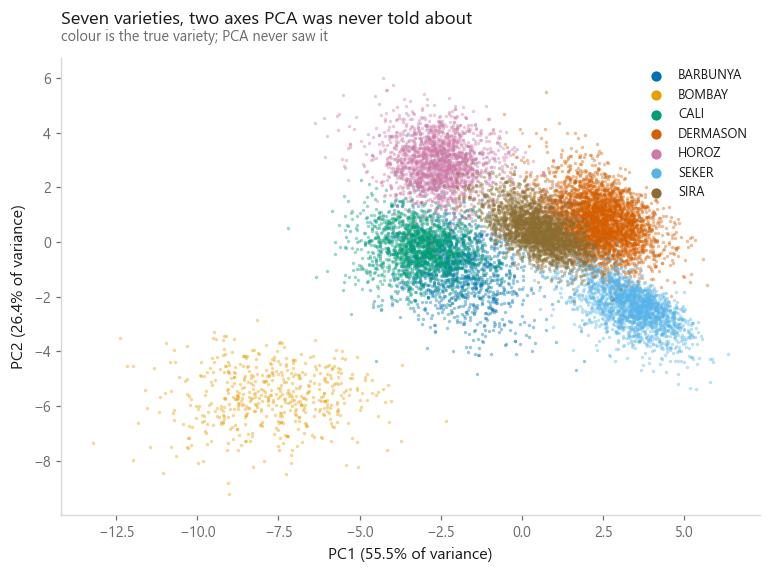

In [4]:
projected = mine.transform(X_scaled)[:, :2]

fig, ax = plt.subplots(figsize=(8.2, 5.4))
for i, variety in enumerate(sorted(y.unique())):
    sel = (y == variety).values
    ax.scatter(projected[sel, 0], projected[sel, 1], s=5, alpha=0.40,
               c=style.PALETTE[i], linewidths=0, label=variety)
ax.set_xlabel(f"PC1 ({ratio[0]:.1%} of variance)")
ax.set_ylabel(f"PC2 ({ratio[1]:.1%} of variance)")
ax.grid(False)
legend = ax.legend(loc="upper right", markerscale=3, fontsize=8.5)
for handle in legend.legend_handles:
    handle.set_alpha(1)
style.title(ax, "Seven varieties, two axes PCA was never told about",
            "colour is the true variety; PCA never saw it")
style.save(fig, FIG / "fig-02-projection.png")

PCA is **unsupervised** — it never saw the varieties. It only looked for
directions of large variance. That the varieties come out largely separated
along those directions says the thing distinguishing them is also the thing they
vary most in, which is size and elongation.

### What the components actually mean

Each component is a weighted recipe over the original columns, and reading the
weights often tells you what it represents.

PC1, largest weights:
MajorAxisLength    0.326
ShapeFactor2       0.315
Perimeter          0.311
EquivDiameter      0.297
ConvexArea         0.283

PC2, largest weights:
MinorAxisLength    0.343
ShapeFactor1       0.333
AspectRation       0.331
Compactness        0.329
ShapeFactor3       0.328


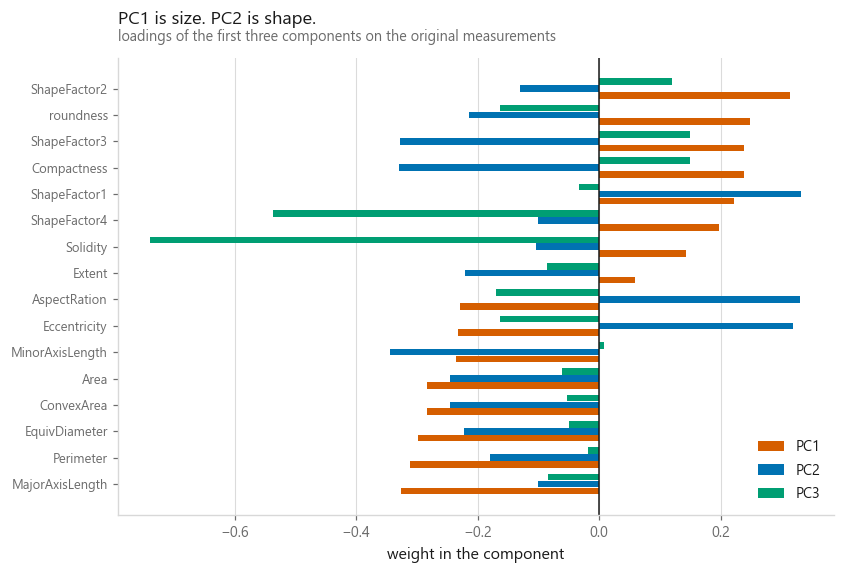

In [5]:
loadings = pd.DataFrame(mine.components_[:3].T, index=X.columns,
                        columns=["PC1", "PC2", "PC3"])

fig, ax = plt.subplots(figsize=(8.4, 5.4))
order = loadings.PC1.sort_values().index
positions = np.arange(len(order))
for offset, column, colour in [(-0.26, "PC1", style.HIGHLIGHT),
                               (0.0, "PC2", style.PALETTE[0]),
                               (0.26, "PC3", style.PALETTE[2])]:
    ax.barh(positions + offset, loadings.loc[order, column], height=0.25,
            color=colour, label=column)
ax.axvline(0, color=style.INK, lw=1)
ax.set_yticks(positions, order, fontsize=8.5)
ax.set_xlabel("weight in the component")
ax.grid(axis="y", visible=False)
ax.grid(axis="x", visible=True)
ax.legend(loc="lower right")
style.title(ax, "PC1 is size. PC2 is shape.",
            "loadings of the first three components on the original measurements")
style.save(fig, FIG / "fig-03-loadings.png")

print("PC1, largest weights:")
print(loadings.PC1.abs().sort_values(ascending=False).head(5).round(3).to_string())
print("\nPC2, largest weights:")
print(loadings.PC2.abs().sort_values(ascending=False).head(5).round(3).to_string())

PC1 loads heavily and in the same direction on `Area`, `Perimeter`,
`ConvexArea`, `EquivDiameter` and the axis lengths. It is measuring **how big
the bean is**, which is why it carries so much variance: those six columns were
always saying the same thing.

PC2 separates elongation from bulk. It is measuring **what shape the bean is**.

Naming components like this is not always possible, and forcing it is a good way
to fool yourself. When it does work it is a real insight into the data.

## 5. When it wins, when it loses

The practical question is whether feeding a model fewer components beats feeding
it everything.

Dry Bean   : all 16 columns 0.9234, best PCA 0.9239 at 10 components
Breast Canc: all 30 columns 0.9807, best PCA 0.9807 at 30 components


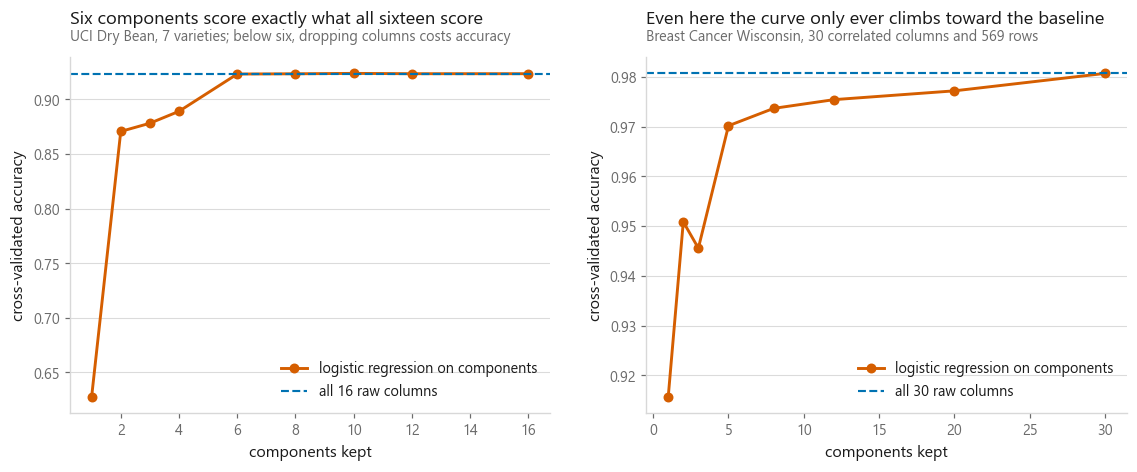

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline

folds = StratifiedKFold(5, shuffle=True, random_state=SEED)
component_counts = [1, 2, 3, 4, 6, 8, 10, 12, 16]
scores = []

for n in component_counts:
    pipeline = make_pipeline(StandardScaler(), PCA(n_components=n, random_state=SEED),
                             LogisticRegression(max_iter=3000))
    scores.append(cross_val_score(pipeline, X.values, y.values, cv=folds, n_jobs=-1).mean())

full = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
                       X.values, y.values, cv=folds, n_jobs=-1).mean()

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.2))

axes[0].plot(component_counts, scores, marker=style.MARKERS[0], color=style.HIGHLIGHT,
             label="logistic regression on components")
axes[0].axhline(full, color=style.PALETTE[0], ls="--", lw=1.4, label="all 16 raw columns")
axes[0].set_xlabel("components kept")
axes[0].set_ylabel("cross-validated accuracy")
axes[0].legend(loc="lower right")
style.title(axes[0], "Six components score exactly what all sixteen score",
            "UCI Dry Bean, 7 varieties; below six, dropping columns costs accuracy")

# Where it does pay: many columns, few rows, heavy correlation.
X_bc, y_bc = datasets.breast_cancer()
bc_counts = [1, 2, 3, 5, 8, 12, 20, 30]
bc_scores = []
for n in bc_counts:
    pipeline = make_pipeline(StandardScaler(), PCA(n_components=n, random_state=SEED),
                             LogisticRegression(max_iter=3000))
    bc_scores.append(cross_val_score(pipeline, X_bc.values, y_bc.values, cv=5, n_jobs=-1).mean())
bc_full = cross_val_score(make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000)),
                          X_bc.values, y_bc.values, cv=5, n_jobs=-1).mean()

axes[1].plot(bc_counts, bc_scores, marker=style.MARKERS[0], color=style.HIGHLIGHT,
             label="logistic regression on components")
axes[1].axhline(bc_full, color=style.PALETTE[0], ls="--", lw=1.4, label="all 30 raw columns")
axes[1].set_xlabel("components kept")
axes[1].set_ylabel("cross-validated accuracy")
axes[1].legend(loc="lower right")
style.title(axes[1], "Even here the curve only ever climbs toward the baseline",
            "Breast Cancer Wisconsin, 30 correlated columns and 569 rows")

style.save(fig, FIG / "fig-04-does-it-help.png")

print(f"Dry Bean   : all 16 columns {full:.4f}, best PCA {max(scores):.4f} "
      f"at {component_counts[int(np.argmax(scores))]} components")
print(f"Breast Canc: all 30 columns {bc_full:.4f}, best PCA {max(bc_scores):.4f} "
      f"at {bc_counts[int(np.argmax(bc_scores))]} components")

The honest answer, on both datasets, is that **PCA never beat using every
column**. Both curves climb toward the baseline and flatten onto it. Neither
rises above it.

I expected the Breast Cancer case to show a clear gain — thirty correlated
columns against only 569 rows is exactly the crowded regime where dropping
dimensions is supposed to pay. It did not. The best score came from keeping all
thirty components, which is just a rotation and no reduction at all.

What PCA did buy is **compression at no cost in accuracy**. On Dry Bean, six
components match all sixteen exactly, so ten columns can go for free. On Breast
Cancer, twelve of thirty land within half a point.

That is genuinely worth having when a model is slow, when storage or bandwidth
matters, or when you need a two-dimensional picture of something with sixteen
axes. It is not an accuracy trick, and material presenting it as one is
overselling it.

Two costs to keep in mind whichever way you go. **You lose interpretability**:
"PC3 went up" is not something you can explain to a domain expert the way
"perimeter went up" is. And **PCA is unsupervised**, so it maximises variance,
not usefulness. A direction with small variance can still be the one that
separates your classes, and PCA will happily discard it.

## Cheat sheet

| | |
|---|---|
| **Use it when** | Columns are correlated; you have more features than you can fit comfortably; you want a two-dimensional picture; you need to speed up a downstream model |
| **Avoid it when** | You need to explain individual features; the structure is non-linear (try [t-SNE](../03-t-sne/) or [UMAP](../04-umap/)); the informative direction has low variance |
| **Scaling needed** | Yes, whenever columns are in different units. Otherwise the largest-unit column becomes PC1 |
| **Main dials** | `n_components`, which may be an integer or a variance fraction like `0.95` |
| **Watch out** | Fit PCA inside the pipeline. Fitting it on all the data before splitting leaks test information into training |
| **Next** | [t-SNE](../03-t-sne/) and [UMAP](../04-umap/), which trade PCA's linear honesty for the ability to unfold curved structure |

## What to remember

1. PCA rotates the axes so that variance piles into the first few.
2. Components are eigenvectors of the covariance matrix; eigenvalues are the
   variance along them.
3. Centre always, scale whenever the units differ.
4. Reading the loadings often names a component. Here PC1 is size and PC2 is shape.
5. It is unsupervised: it maximises variance, not class separation.
6. It reliably helps with compression and visualisation. On neither dataset here
   did it beat simply keeping every column, including the crowded one where I
   expected it to.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [06-03 t-SNE](../03-t-sne/) · Back to [the curriculum](../../CURRICULUM.md)

`#MachineLearning` `#PCA` `#DimensionalityReduction` `#UnsupervisedLearning`
`#Python` `#ScikitLearn` `#DataScience` `#MLTutorial` `#Eigenvectors`